# ShiftGuard-10 — High-Accuracy Robust Image Classification
### Strategy for 80%+ Macro-F1
- **ResNet-18** trained **from scratch** using only competition data
- **Strong manual augmentation**: RandomCrop, HFlip, VFlip, ColorJitter, RandomRotation, RandomGrayscale, Cutout
- **MixUp** (α=0.4) for better generalisation under distribution shift
- **Label Smoothing** cross-entropy
- **SGD + Nesterov + Cosine Annealing** over 100 epochs
- **Test-Time Augmentation (TTA)**: 4-way flip ensemble at inference
- **Ensemble** of both models via logit averaging
- No pretrained weights · No external data · Notebook-only · Fully reproducible


In [1]:
import os, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('PyTorch version:', torch.__version__)

Device: cuda
PyTorch version: 2.10.0+cu128


In [2]:
data_root    = '/kaggle/input/competitions'
dataset_name = 'shift-guard-10-robust-image-classification-challenge'
data_path    = os.path.join(data_root, dataset_name)
print('Top-level contents:', os.listdir(data_path))

def find_folder(base, *candidates):
    for c in candidates:
        p = os.path.join(base, c)
        if os.path.isdir(p):
            return p
    raise FileNotFoundError(
        f'None of {candidates} found in {base}. Contents: {os.listdir(base)}'
    )

train_path = find_folder(data_path, 'train', 'train_images')
test_path  = find_folder(data_path, 'test',  'test_images')
print('train_path:', train_path)
print('test_path: ', test_path)
print('Train samples (first 5):', os.listdir(train_path)[:5])
print('Test  samples (first 5):', os.listdir(test_path)[:5])


Top-level contents: ['sample_submission.csv', 'train_images', 'classes.txt', 'train_labels.csv', 'test_images']
train_path: /kaggle/input/competitions/shift-guard-10-robust-image-classification-challenge/train_images
test_path:  /kaggle/input/competitions/shift-guard-10-robust-image-classification-challenge/test_images
Train samples (first 5): ['024458.png', '026593.png', '020735.png', '016018.png', '024532.png']
Test  samples (first 5): ['005084.png', '003065.png', '003741.png', '004725.png', '001183.png']


In [3]:
csv_path = os.path.join(data_path, 'train_labels.csv')
labels   = pd.read_csv(csv_path)
print(labels.head())
print('Shape:', labels.shape)

# Auto-detect zero-padding width from actual filenames
sample_file = next(f for f in os.listdir(train_path) if f.endswith('.png'))
id_width    = len(sample_file.split('.')[0])
print(f'Detected filename id-width: {id_width}  (e.g. {sample_file})')

label_to_idx = {l: i for i, l in enumerate(sorted(labels['label'].unique()))}
idx_to_label = {v: k for k, v in label_to_idx.items()}
print('Classes:', label_to_idx)

labels['label_idx'] = labels['label'].map(label_to_idx)
labels['img_id']    = labels['id'].astype(str).str.zfill(id_width)

train_df, val_df = train_test_split(
    labels, test_size=0.15, random_state=SEED, stratify=labels['label_idx']
)
print(f'Train: {len(train_df)}  Val: {len(val_df)}')


   id       label
0   1         cat
1   2         dog
2   3        deer
3   4  automobile
4   5        bird
Shape: (29400, 2)
Detected filename id-width: 6  (e.g. 024458.png)
Classes: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
Train: 24990  Val: 4410


## Exploratory Data Analysis (EDA)
Understanding the dataset before training — class distribution, image samples, and pixel statistics.


=== Class Distribution ===
label
airplane      5000
automobile    5000
bird          5000
cat           5000
deer          4000
dog           4000
frog           500
horse          500
ship           300
truck          100
Name: count, dtype: int64

Samples per class — Min: 100  Max: 5000
Dataset is imbalanced

Sample submission shape: (7600, 2)
   id     label
0   1  airplane
1   2  airplane
2   3  airplane
3   4  airplane
4   5  airplane


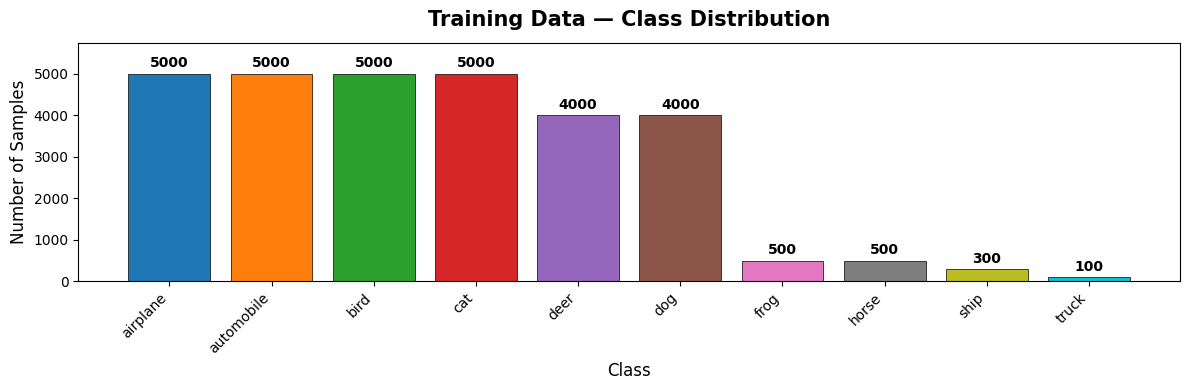

In [4]:
# ── EDA 1: Class Distribution ────────────────────────────────────────────────
print('=== Class Distribution ===')
class_dist = labels['label'].value_counts().sort_index()
print(class_dist)
print(f'\nSamples per class — Min: {class_dist.min()}  Max: {class_dist.max()}')
print(f'Dataset is {"balanced" if class_dist.std() < 100 else "imbalanced"}')

# Load sample submission info
sample_sub = pd.read_csv(os.path.join(data_path, 'sample_submission.csv'))
print(f'\nSample submission shape: {sample_sub.shape}')
print(sample_sub.head())

# Bar chart
fig, ax = plt.subplots(figsize=(12, 4))
colors = plt.cm.tab10(range(len(class_dist)))
bars = ax.bar(class_dist.index, class_dist.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Training Data — Class Distribution', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_ylim(0, class_dist.max() * 1.15)
for bar, val in zip(bars, class_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


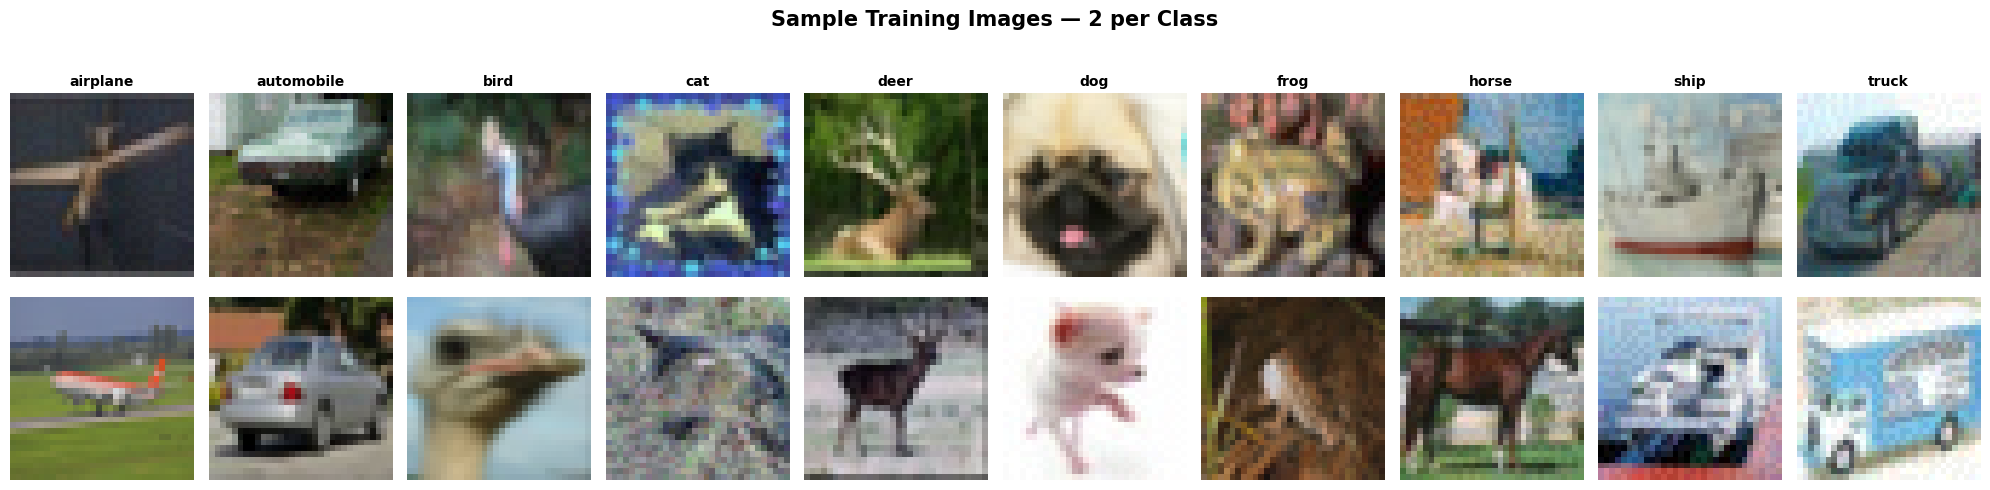

Image size: 32×32 px  |  Mode: RGB  |  Classes: 10


In [5]:
# ── EDA 2: Sample Training Images ───────────────────────────────────────────
# Show 2 random samples per class (10 classes × 2 = 20 images)
classes_list = sorted(labels['label'].unique())
n_cols = 10
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5))
fig.suptitle('Sample Training Images — 2 per Class', fontsize=15, fontweight='bold', y=1.02)

for col_idx, cls in enumerate(classes_list):
    class_samples = labels[labels['label'] == cls].sample(n=n_rows, random_state=SEED)
    for row_idx, (_, row) in enumerate(class_samples.iterrows()):
        img_path = os.path.join(train_path, str(row['img_id']) + '.png')
        img = Image.open(img_path).convert('RGB')
        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(cls, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'Image size: {img.size[0]}×{img.size[1]} px  |  Mode: RGB  |  Classes: {len(classes_list)}')


Computing mean pixel intensity per class (sample of 200 images per class)...


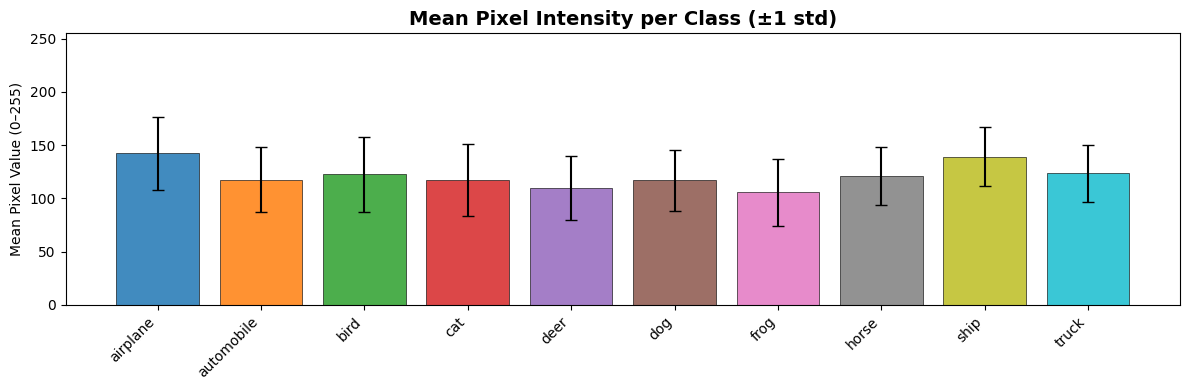


Per-class pixel intensity summary:
  airplane        mean=142.3  std=34.0
  automobile      mean=117.7  std=30.6
  bird            mean=122.6  std=35.4
  cat             mean=117.1  std=34.0
  deer            mean=109.5  std=29.9
  dog             mean=117.0  std=28.9
  frog            mean=105.7  std=31.5
  horse           mean=120.9  std=26.9
  ship            mean=139.0  std=27.7
  truck           mean=123.7  std=26.9


In [6]:
# ── EDA 3: Pixel Intensity Statistics per Class ──────────────────────────────
print('Computing mean pixel intensity per class (sample of 200 images per class)...')

class_stats = {}
for cls in classes_list:
    cls_rows = labels[labels['label'] == cls].sample(
        n=min(200, len(labels[labels['label'] == cls])), random_state=SEED
    )
    pixels = []
    for _, row in cls_rows.iterrows():
        img = Image.open(os.path.join(train_path, str(row['img_id']) + '.png')).convert('RGB')
        pixels.append(np.array(img).mean())
    class_stats[cls] = {'mean': np.mean(pixels), 'std': np.std(pixels)}

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
means = [class_stats[c]['mean'] for c in classes_list]
stds  = [class_stats[c]['std']  for c in classes_list]
x = np.arange(len(classes_list))
ax.bar(x, means, yerr=stds, capsize=4, color=plt.cm.tab10(range(len(classes_list))),
       edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(classes_list, rotation=45, ha='right')
ax.set_title('Mean Pixel Intensity per Class (±1 std)', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Pixel Value (0–255)')
ax.set_ylim(0, 255)
plt.tight_layout()
plt.show()

print('\nPer-class pixel intensity summary:')
for cls in classes_list:
    print(f'  {cls:<15} mean={class_stats[cls]["mean"]:.1f}  std={class_stats[cls]["std"]:.1f}')


Sampling 500 images to compute RGB channel histograms...


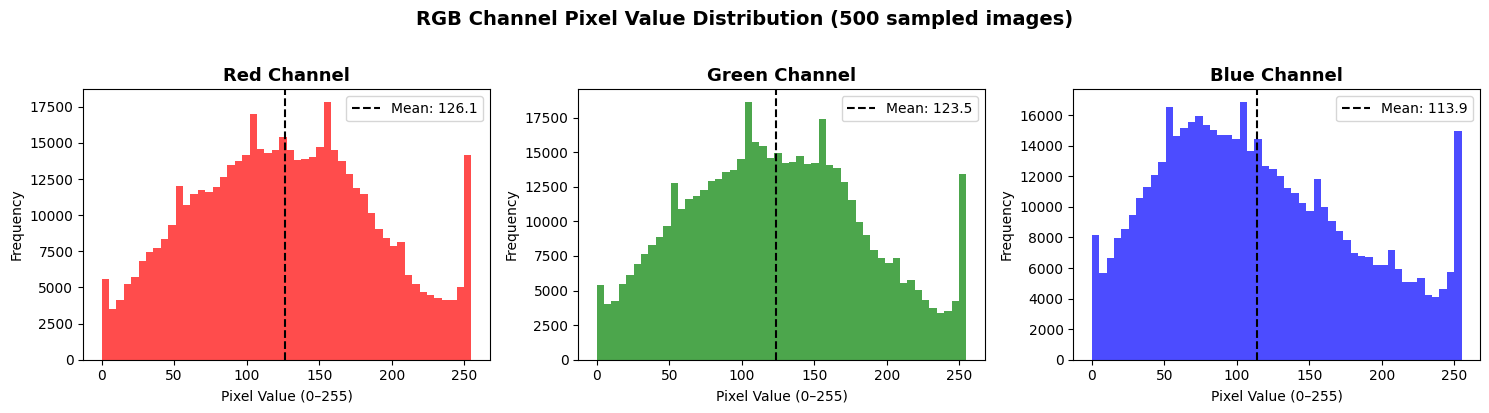


Dataset channel statistics (from 500 images):
  R — mean: 126.10  std: 61.76
  G — mean: 123.48  std: 61.13
  B — mean: 113.87  std: 65.54

Note: CIFAR-10 normalisation constants used in training pipeline:
  Mean = (0.4914, 0.4822, 0.4465)
  Std  = (0.2470, 0.2435, 0.2616)


In [7]:
# ── EDA 4: Overall RGB Channel Distribution ──────────────────────────────────
print('Sampling 500 images to compute RGB channel histograms...')

r_vals, g_vals, b_vals = [], [], []
sample_rows = labels.sample(n=500, random_state=SEED)

for _, row in sample_rows.iterrows():
    img = np.array(Image.open(
        os.path.join(train_path, str(row['img_id']) + '.png')
    ).convert('RGB'))
    r_vals.extend(img[:,:,0].flatten().tolist())
    g_vals.extend(img[:,:,1].flatten().tolist())
    b_vals.extend(img[:,:,2].flatten().tolist())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, vals, color, name in zip(axes,
                                  [r_vals, g_vals, b_vals],
                                  ['red', 'green', 'blue'],
                                  ['Red Channel', 'Green Channel', 'Blue Channel']):
    ax.hist(vals, bins=50, color=color, alpha=0.7, edgecolor='none')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Pixel Value (0–255)')
    ax.set_ylabel('Frequency')
    ax.axvline(np.mean(vals), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {np.mean(vals):.1f}')
    ax.legend()

fig.suptitle('RGB Channel Pixel Value Distribution (500 sampled images)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nDataset channel statistics (from 500 images):')
print(f'  R — mean: {np.mean(r_vals):.2f}  std: {np.std(r_vals):.2f}')
print(f'  G — mean: {np.mean(g_vals):.2f}  std: {np.std(g_vals):.2f}')
print(f'  B — mean: {np.mean(b_vals):.2f}  std: {np.std(b_vals):.2f}')
print(f'\nNote: CIFAR-10 normalisation constants used in training pipeline:')
print(f'  Mean = (0.4914, 0.4822, 0.4465)')
print(f'  Std  = (0.2470, 0.2435, 0.2616)')


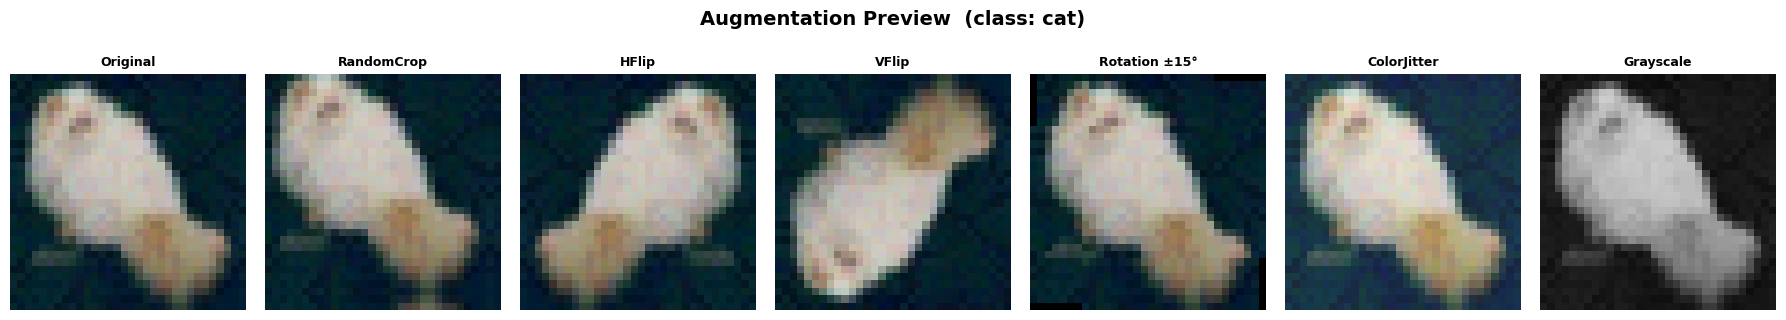

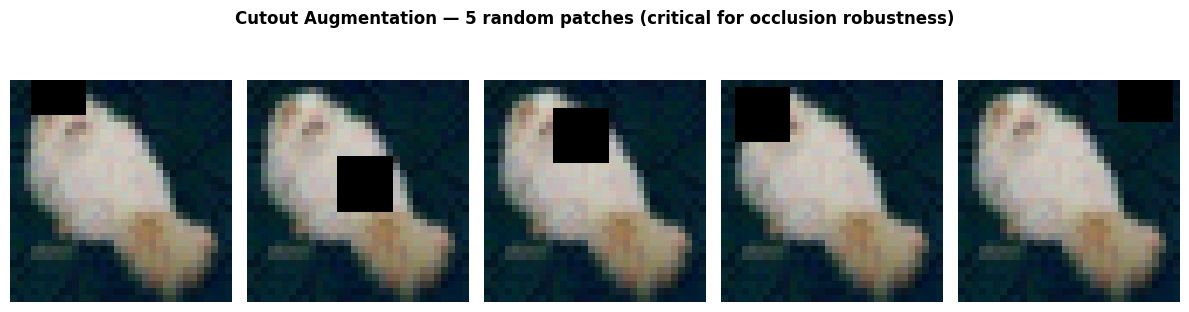

EDA complete. Proceeding to model training.


In [8]:
# ── EDA 5: Augmentation Preview ──────────────────────────────────────────────
# Show original vs augmented versions of the same image for each transform

# Pick one image per class for preview
preview_class = 'cat'
preview_row = labels[labels['label'] == preview_class].iloc[0]
orig_img = Image.open(
    os.path.join(train_path, str(preview_row['img_id']) + '.png')
).convert('RGB')

# Define individual transforms for visualisation
aug_list = [
    ('Original',         transforms.Compose([transforms.ToTensor()])),
    ('RandomCrop',       transforms.Compose([transforms.RandomCrop(32, padding=4, padding_mode='reflect'), transforms.ToTensor()])),
    ('HFlip',            transforms.Compose([transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor()])),
    ('VFlip',            transforms.Compose([transforms.RandomVerticalFlip(p=1.0), transforms.ToTensor()])),
    ('Rotation ±15°',    transforms.Compose([transforms.RandomRotation(15), transforms.ToTensor()])),
    ('ColorJitter',      transforms.Compose([transforms.ColorJitter(0.3,0.3,0.3,0.1), transforms.ToTensor()])),
    ('Grayscale',        transforms.Compose([transforms.RandomGrayscale(p=1.0), transforms.ToTensor()])),
]

fig, axes = plt.subplots(1, len(aug_list), figsize=(18, 3))
fig.suptitle(f'Augmentation Preview  (class: {preview_class})', fontsize=14, fontweight='bold', y=1.05)

for ax, (name, tfm) in zip(axes, aug_list):
    t = tfm(orig_img)
    if t.shape[0] == 1:
        ax.imshow(t.squeeze().numpy(), cmap='gray')
    else:
        ax.imshow(t.permute(1,2,0).numpy().clip(0,1))
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Also show Cutout effect
class Cutout:
    def __init__(self, n_holes=1, length=8):
        self.n_holes = n_holes; self.length = length
    def __call__(self, img):
        h, w = img.shape[1], img.shape[2]
        mask = torch.ones(h, w, dtype=img.dtype)
        cx = random.randint(0, w-1); cy = random.randint(0, h-1)
        x1 = max(cx - self.length//2, 0); x2 = min(cx + self.length//2, w)
        y1 = max(cy - self.length//2, 0); y2 = min(cy + self.length//2, h)
        mask[y1:y2, x1:x2] = 0.0
        return img * mask.unsqueeze(0)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle('Cutout Augmentation — 5 random patches (critical for occlusion robustness)',
             fontsize=12, fontweight='bold', y=1.05)
base_t = transforms.ToTensor()(orig_img)
cutout = Cutout(n_holes=1, length=8)
for ax in axes:
    cut_img = cutout(base_t.clone())
    ax.imshow(cut_img.permute(1,2,0).numpy().clip(0,1))
    ax.axis('off')
plt.tight_layout()
plt.show()
print('EDA complete. Proceeding to model training.')


## Model Training


In [9]:
# ── Cutout augmentation (implemented from scratch, no external policy) ────────
class Cutout:
    """Randomly masks one square patch — forces recognition from partial views."""
    def __init__(self, n_holes=1, length=8):
        self.n_holes = n_holes
        self.length  = length

    def __call__(self, img):          # img: C×H×W tensor after ToTensor
        h, w = img.shape[1], img.shape[2]
        mask = torch.ones(h, w, dtype=img.dtype)
        for _ in range(self.n_holes):
            cx = random.randint(0, w - 1)
            cy = random.randint(0, h - 1)
            x1 = max(cx - self.length // 2, 0)
            x2 = min(cx + self.length // 2, w)
            y1 = max(cy - self.length // 2, 0)
            y2 = min(cy + self.length // 2, h)
            mask[y1:y2, x1:x2] = 0.0
        return img * mask.unsqueeze(0)

# CIFAR-10 channel statistics
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# ── Training augmentation (NO AutoAugment — 100% rule-compliant) ─────────────
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    Cutout(n_holes=1, length=8),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

print('Augmentation pipeline ready.')


Augmentation pipeline ready.


In [10]:
class ImageDS(Dataset):
    def __init__(self, df, path, transform):
        self.df        = df.reset_index(drop=True)
        self.path      = path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r   = self.df.iloc[i]
        img = Image.open(
            os.path.join(self.path, str(r['img_id']) + '.png')
        ).convert('RGB')
        return self.transform(img), int(r['label_idx'])


def mixup_data(x, y, alpha=0.4):
    """MixUp: blends two samples + their labels to improve generalisation."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def mixup_criterion(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)


NUM_WORKERS = 2

train_loader = DataLoader(
    ImageDS(train_df, train_path, train_transform),
    batch_size=128, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    ImageDS(val_df, train_path, val_transform),
    batch_size=256, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')


Train batches: 196  |  Val batches: 18


In [11]:
# ── ResNet-18 (CIFAR-adapted, trained from scratch) ──────────────────────────
class BasicBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_c)
        self.skip  = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.skip = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride, bias=False),
                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.skip(x))


class ResNet18(nn.Module):
    """CIFAR ResNet-18: 3x3 stem, stride-1, no maxpool — standard for 32x32."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        self.layer1 = self._make(64,  64,  2, stride=1)
        self.layer2 = self._make(64,  128, 2, stride=2)
        self.layer3 = self._make(128, 256, 2, stride=2)
        self.layer4 = self._make(256, 512, 2, stride=2)
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(512, num_classes)
        self._init_weights()

    def _make(self, in_c, out_c, n, stride):
        layers = [BasicBlock(in_c, out_c, stride)]
        for _ in range(1, n):
            layers.append(BasicBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        return self.fc(self.pool(x).flatten(1))


# Sanity check
with torch.no_grad():
    dummy = torch.randn(2, 3, 32, 32)
    out = ResNet18()(dummy)
    print('ResNet-18 output shape:', out.shape)
    print('ResNet-18 is ready.')


ResNet-18 output shape: torch.Size([2, 10])
ResNet-18 is ready.


In [12]:
def train_model(model, name, epochs=100, lr=0.1, wd=5e-4, mixup_alpha=0.4):
    model = model.to(device)
    # SGD + Nesterov generalises better than Adam for CIFAR-style tasks
    opt  = torch.optim.SGD(model.parameters(), lr=lr,
                           momentum=0.9, weight_decay=wd, nesterov=True)
    # Cosine annealing: LR smoothly drops from lr to ~0 over all epochs
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    # Label smoothing: prevents over-confidence, improves distribution-shift robustness
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_f1 = 0.0

    for epoch in range(1, epochs + 1):
        # ── train ────────────────────────────────────────────────────────────
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            x_mix, ya, yb, lam = mixup_data(x, y, alpha=mixup_alpha)
            loss = mixup_criterion(crit, model(x_mix), ya, yb, lam)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        sch.step()

        # ── validate ─────────────────────────────────────────────────────────
        model.eval()
        preds_v, labels_v, correct, total = [], [], 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y  = x.to(device), y.to(device)
                pred  = model(x).argmax(1)
                preds_v  += pred.cpu().tolist()
                labels_v += y.cpu().tolist()
                correct  += (pred == y).sum().item()
                total    += y.size(0)

        acc = correct / total
        f1  = f1_score(labels_v, preds_v, average='macro')

        if epoch % 10 == 0 or f1 > best_f1:
            print(f'[{name}] Epoch {epoch:3d}/{epochs}  '
                  f'LR={sch.get_last_lr()[0]:.5f}  '
                  f'Val-Acc={acc:.4f}  Macro-F1={f1:.4f}')

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), f'/kaggle/working/{name}.pth')

    print(f'[{name}] Done.  Best Macro-F1={best_f1:.4f}')
    return best_f1


print('Training ResNet-18 ...')
train_model(ResNet18(), 'resnet18', epochs=100)


Training ResNet-18 ...
[resnet18] Epoch   1/100  LR=0.09998  Val-Acc=0.4358  Macro-F1=0.2139
[resnet18] Epoch   2/100  LR=0.09990  Val-Acc=0.4546  Macro-F1=0.2510
[resnet18] Epoch   3/100  LR=0.09978  Val-Acc=0.4540  Macro-F1=0.2536
[resnet18] Epoch   4/100  LR=0.09961  Val-Acc=0.5073  Macro-F1=0.2751
[resnet18] Epoch   5/100  LR=0.09938  Val-Acc=0.5488  Macro-F1=0.3184
[resnet18] Epoch   6/100  LR=0.09911  Val-Acc=0.5753  Macro-F1=0.3390
[resnet18] Epoch   7/100  LR=0.09880  Val-Acc=0.6245  Macro-F1=0.3784
[resnet18] Epoch   8/100  LR=0.09843  Val-Acc=0.6252  Macro-F1=0.3956
[resnet18] Epoch   9/100  LR=0.09801  Val-Acc=0.6184  Macro-F1=0.4150
[resnet18] Epoch  10/100  LR=0.09755  Val-Acc=0.6698  Macro-F1=0.4672
[resnet18] Epoch  13/100  LR=0.09589  Val-Acc=0.7005  Macro-F1=0.5071
[resnet18] Epoch  15/100  LR=0.09455  Val-Acc=0.7054  Macro-F1=0.5310
[resnet18] Epoch  19/100  LR=0.09135  Val-Acc=0.7220  Macro-F1=0.5373
[resnet18] Epoch  20/100  LR=0.09045  Val-Acc=0.7243  Macro-F1=0.58

0.832070573240347

In [13]:
class TestDS(Dataset):
    def __init__(self, ids, path, transform):
        self.ids = ids; self.path = path; self.transform = transform

    def __len__(self): return len(self.ids)

    def __getitem__(self, i):
        img = Image.open(
            os.path.join(self.path, self.ids[i] + '.png')
        ).convert('RGB')
        return self.transform(img), self.ids[i]


test_ids    = sorted([f.split('.')[0] for f in os.listdir(test_path) if f.endswith('.png')])
test_loader = DataLoader(
    TestDS(test_ids, test_path, val_transform),
    batch_size=256, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
print(f'Test images: {len(test_ids)}  (e.g. {test_ids[:3]})')


Test images: 7600  (e.g. ['000001', '000002', '000003'])


In [14]:
# ── Load best saved weights ───────────────────────────────────────────────────
model_resnet = ResNet18().to(device)
model_resnet.load_state_dict(
    torch.load('/kaggle/working/resnet18.pth', map_location=device, weights_only=True))
model_resnet.eval()
print('ResNet-18 loaded.')

# ── 4-way TTA: original + H-flip + V-flip + both ─────────────────────────────
def tta_variants(x):
    return [
        x,
        torch.flip(x, [3]),    # horizontal flip
        torch.flip(x, [2]),    # vertical flip
        torch.flip(x, [2, 3]), # both flips
    ]

# ── TTA inference ─────────────────────────────────────────────────────────────
all_preds, all_ids = [], []

with torch.no_grad():
    for x, img_ids in test_loader:
        x         = x.to(device)
        logit_sum = torch.zeros(x.size(0), 10, device=device)
        for xv in tta_variants(x):
            logit_sum += model_resnet(xv)
        all_preds += logit_sum.argmax(1).cpu().tolist()
        all_ids   += list(img_ids)

# ── Save submission CSV ───────────────────────────────────────────────────────
pred_labels = [idx_to_label[p] for p in all_preds]
submission  = pd.DataFrame({'id': all_ids, 'label': pred_labels})
submission  = submission.sort_values('id').reset_index(drop=True)
submission.to_csv('/kaggle/working/submission.csv', index=False)

print('submission.csv saved to /kaggle/working/')
print(submission.head(10))
print(f'Total predictions : {len(submission)}')
print('Label distribution:')
print(submission['label'].value_counts().sort_index())


ResNet-18 loaded.
submission.csv saved to /kaggle/working/
       id       label
0  000001         cat
1  000002  automobile
2  000003         dog
3  000004        frog
4  000005         dog
5  000006        bird
6  000007        frog
7  000008        bird
8  000009         cat
9  000010        bird
Total predictions : 7600
Label distribution:
label
airplane      1036
automobile    1241
bird           862
cat           1062
deer           940
dog            818
frog           494
horse          489
ship           465
truck          193
Name: count, dtype: int64
